### Model Neurons Overlap

In [ ]:
import json 

def check_overlap(file_paths, label):
    neurons_list = []
    for file_path in file_paths:
        with open(file_path, "r") as f:
            neurons_list.append(json.load(f)["neurons"])
    
    for top_n in [0.4]:  # , 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
        sum_overlap = []
        for layer_nb in range(4, 27):
            top_neurons_all = []
            for neurons in neurons_list:
                layer_neurons = neurons[layer_nb]
                n = int(len(layer_neurons) * top_n)
                top_neurons_all.append(set(layer_neurons[:n]))
            common_indices = set.intersection(*top_neurons_all)
            avg_set_size = sum(len(s) for s in top_neurons_all) / len(top_neurons_all)
            overlap_percentage = (len(common_indices) / avg_set_size) * 100 if avg_set_size > 0 else 0
            sum_overlap.append(overlap_percentage)
        print(f"{label}: {sum(sum_overlap) / len(sum_overlap):.2f}%")
        

check_overlap(["insights_files/neuron_fileswmt16-de-en/all.json", "insights_files/nneuron_filesiqa/all.json"], "wmt16-de-en vs piqa")
check_overlap(["insights_files/neuron_fileswmt16-de-en/all.json", "insights_files/nneuron_filesnn_dailymail/all.json"], "wmt16-de-en vs cnn_dailymail")
check_overlap(["insights_files/neuron_filespiqa/all.json", "insights_files/nneuron_filesnn_dailymail/all.json"], "piqa vs cnn_dailymail")

# Check overlap between all 3
check_overlap(["insights_files/neuron_filespiqa/all.json",
               "insights_files/neuron_filescnn_dailymail/all.json",
               "insights_files/neuron_fileswmt16-de-en/all.json"
               ], "All three datasets")

wmt16-de-en vs piqa: 67.94%
wmt16-de-en vs cnn_dailymail: 72.86%
piqa vs cnn_dailymail: 71.85%
All three datasets: 59.90%


### Prove that neurons overlap exist for each different task

In [ ]:
import json

datasets_common_indices = []
for dataset in ["piqa", "wmt16-de-en", "cnn_dailymail"]:
    neurons = []
    for i in range(0, 10):
        file_path = f"./insights_files/neuron_files{dataset}/{i}.json"
        with open(file_path, "r") as f:
            n = json.load(f)["neurons"]
            neurons.append(n)
        
    for top_n in [0.4]: # , 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
        sum_overlap = []
        for layer_nb in range(4, 27):
            top_neurons_all = []
            for neurons_file in neurons:
                file_layer_neurons = neurons_file[layer_nb]
                
                n = int(len(file_layer_neurons) * top_n)
                first_n_file = set(file_layer_neurons[:n])
                top_neurons_all.append(first_n_file)
                
            common_indices = set.intersection(*top_neurons_all)
            datasets_common_indices.append(common_indices)
            avg_set_size = sum(len(s) for s in top_neurons_all) / len(top_neurons_all)
            overlap_percentage = (len(common_indices) / avg_set_size) * 100
            
            sum_overlap.append(overlap_percentage)
            # print(f"Layer {layer_nb}: {overlap_percentage:.2f}% overlap in first {int(top_n*100)}%")
            
        print(f"{dataset}: Avg in top {int(top_n*100)}%: {sum(sum_overlap) / len(sum_overlap)}")

piqa: Avg in top 40%: 58.48595848595851
wmt16-de-en: Avg in top 40%: 65.13510643945426
cnn_dailymail: Avg in top 40%: 69.58247066942718


### Prove that they are different for each task

In [12]:
new_set = datasets_common_indices[0] & datasets_common_indices[1]
print(len(new_set) / ((len(datasets_common_indices[0]) + len(datasets_common_indices[1])) / 2))

new_set = datasets_common_indices[0] & datasets_common_indices[2]
print(len(new_set) / ((len(datasets_common_indices[0]) + len(datasets_common_indices[2])) / 2))

new_set = datasets_common_indices[3] & datasets_common_indices[2]
print(len(new_set) / ((len(datasets_common_indices[3]) + len(datasets_common_indices[2])) / 2))

0.22729715206878023
0.2364917776037588
0.2438153532262178


# Draw Results

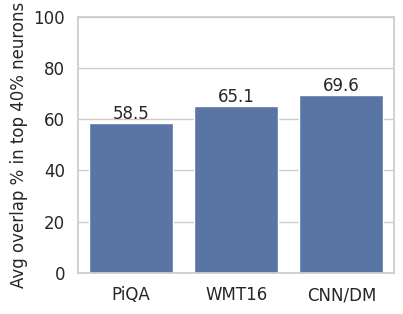

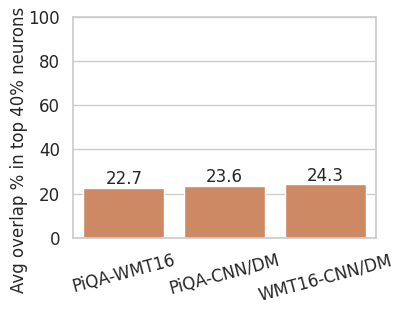

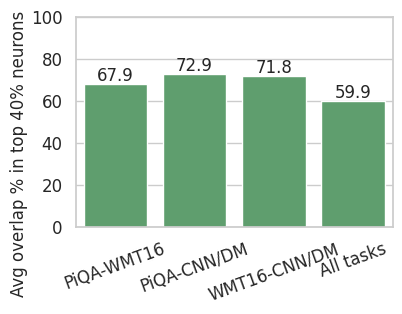

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Global style for paper-quality plots
sns.set_theme(style="whitegrid")
FIGSIZE = (4.2, 3.3)   # consistent size for all figures (good for 2-column papers)
FONTSIZE = 12

# -------------------------------
# 1. Task-specific overlaps (intra-task)
# -------------------------------
task_specific = {
    "PiQA": 58.485,
    "WMT16": 65.135,
    "CNN/DM": 69.582
}

plt.figure(figsize=FIGSIZE)
sns.barplot(x=list(task_specific.keys()),
            y=list(task_specific.values()),
            color="#4C72B0")

plt.ylabel("Avg overlap % in top 40% neurons", fontsize=FONTSIZE)
plt.ylim(0, 100)
plt.xticks(fontsize=FONTSIZE)
plt.yticks(fontsize=FONTSIZE)

for i, v in enumerate(task_specific.values()):
    plt.text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=FONTSIZE)

plt.tight_layout()
plt.savefig("task-specific-neurons-insight.pdf")
plt.show()


# -------------------------------
# 2. Cross-task overlaps (inter-task)
# -------------------------------
cross_task = {
    "PiQA-WMT16": 22.7,
    "PiQA-CNN/DM": 23.6,
    "WMT16-CNN/DM": 24.3
}

plt.figure(figsize=FIGSIZE)
sns.barplot(x=list(cross_task.keys()),
            y=list(cross_task.values()),
            color="#DD8452")

plt.ylabel("Avg overlap % in top 40% neurons", fontsize=FONTSIZE)
plt.ylim(0, 100)
ax = plt.gca()
ax.yaxis.set_label_coords(-0.15, 0.4) 
plt.xticks(fontsize=FONTSIZE, rotation=15)
plt.yticks(fontsize=FONTSIZE)

for i, v in enumerate(cross_task.values()):
    plt.text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=FONTSIZE)

plt.tight_layout()
plt.savefig("task-specific-overlap.pdf")
plt.show()


# -------------------------------
# 3. Model-level neuron overlap
# -------------------------------
model_neurons = {
    "PiQA-WMT16": 67.94,
    "PiQA-CNN/DM": 72.86,
    "WMT16-CNN/DM": 71.85,
    "All tasks": 59.90
}

plt.figure(figsize=FIGSIZE)
sns.barplot(x=list(model_neurons.keys()),
            y=list(model_neurons.values()),
            color="#55A868")

plt.ylabel("Avg overlap % in top 40% neurons", fontsize=FONTSIZE)
ax = plt.gca()
ax.yaxis.set_label_coords(-0.15, 0.35) 
plt.ylim(0, 100)
plt.xticks(fontsize=FONTSIZE, rotation=20)
plt.yticks(fontsize=FONTSIZE)

for i, v in enumerate(model_neurons.values()):
    plt.text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=FONTSIZE)

plt.tight_layout()
plt.savefig("model-neurons-insight.pdf")
plt.show()